In [1]:
# Dynamic Transportation Factor Laboratory
# General Overview of the Plan

In [2]:
# Welcome to Japeshwar Singh's project, but please call me Jay :)
# This moves up a folder to access the .py data
import sys
import os
print("Path:", os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('..'))

Path: C:\Users\japes\airline_factor_lab


In [3]:
# The Classics
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt
import models as md
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok = True)
print("data.py found:", os.path.exists('../data.py'))

data.py found: True


In [4]:
# Starting Data
stocks_returns, macro_returns, prices = dt.load_data()
print(f"Shape: {stocks_returns.shape}")
stocks_returns.head()

Stocks: 20 tickers
Macro columns: ['SPY', 'IYT', 'Brent', 'VIX']
Dates: 2336 trading days
Range: 2017-04-07 -> 2026-07-30
Shape: (2336, 20)


Ticker,DAL,UAL,AAL,LUV,ALK,JBLU,UNP,CSX,NSC,CP,CNI,UPS,FDX,JBHT,ODFL,KNX,SAIA,SNDR,CHRW,EXPD
Date,,,,,,,,,,,,,,,,,,,,
2017-04-07,-0.001991,0.009355,0.002155,0.021498,-0.002911,0.009046,-0.000374,-0.005886,0.000173,-0.000932,-0.006655,-0.015875,-0.001736,-0.012764,-0.008374,0.008191,-0.009174,0.000000,-0.007236,-0.012474
2017-04-10,-0.004437,0.008989,0.012124,-0.005884,-0.001459,0.007084,0.005497,0.005257,-0.003544,0.018547,0.016219,0.013528,0.000562,0.023224,0.014669,0.087081,0.025030,0.016184,0.006712,0.007147
2017-04-11,0.007091,-0.011390,0.037338,0.015374,-0.002249,0.013555,-0.000093,-0.009906,-0.002341,0.000392,-0.008482,-0.006316,-0.014250,-0.017422,-0.006056,-0.036634,-0.013575,-0.032635,-0.006448,-0.003567
2017-04-12,-0.005313,-0.011092,0.000683,0.008140,-0.002028,-0.015910,-0.019140,-0.017306,-0.030221,-0.014220,-0.008145,-0.014478,-0.035227,-0.015955,-0.022890,-0.066331,-0.037127,0.014343,-0.012754,-0.004836
2017-04-13,-0.022902,-0.012374,-0.013973,-0.021855,-0.026632,-0.022419,-0.007511,0.000431,-0.001880,-0.005385,-0.006427,-0.004712,-0.013944,-0.011378,-0.017952,-0.011227,-0.016687,0.001054,-0.004422,-0.006304


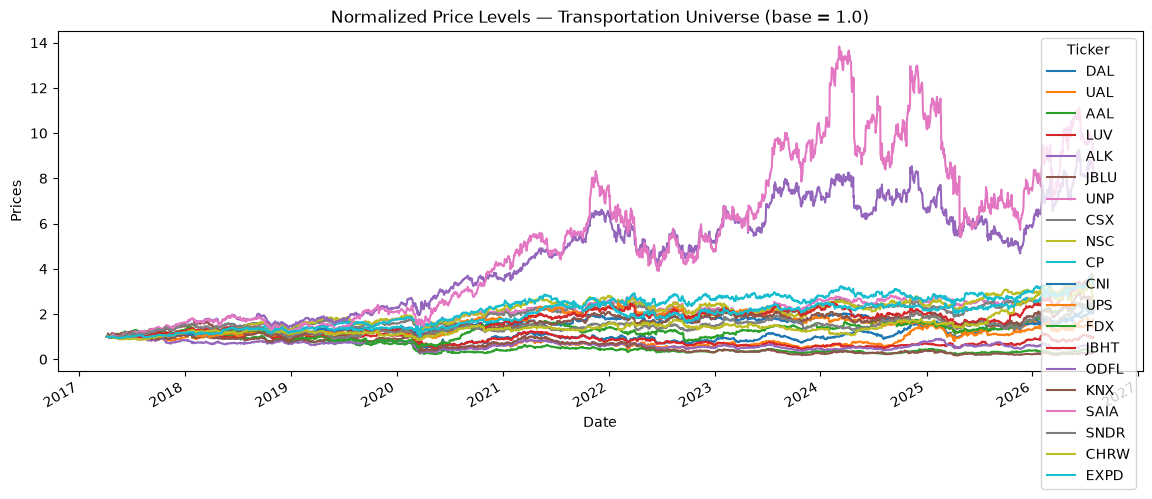

In [5]:
# Let's consider the log price levels of our desired assets 
(prices[dt.stocks].dropna() /
 prices[dt.stocks].dropna().iloc[0]).plot(figsize = (14,5), title = "Normalized Price Levels — Transportation Universe (base = 1.0)")
plt.ylabel("Prices")
plt.show()

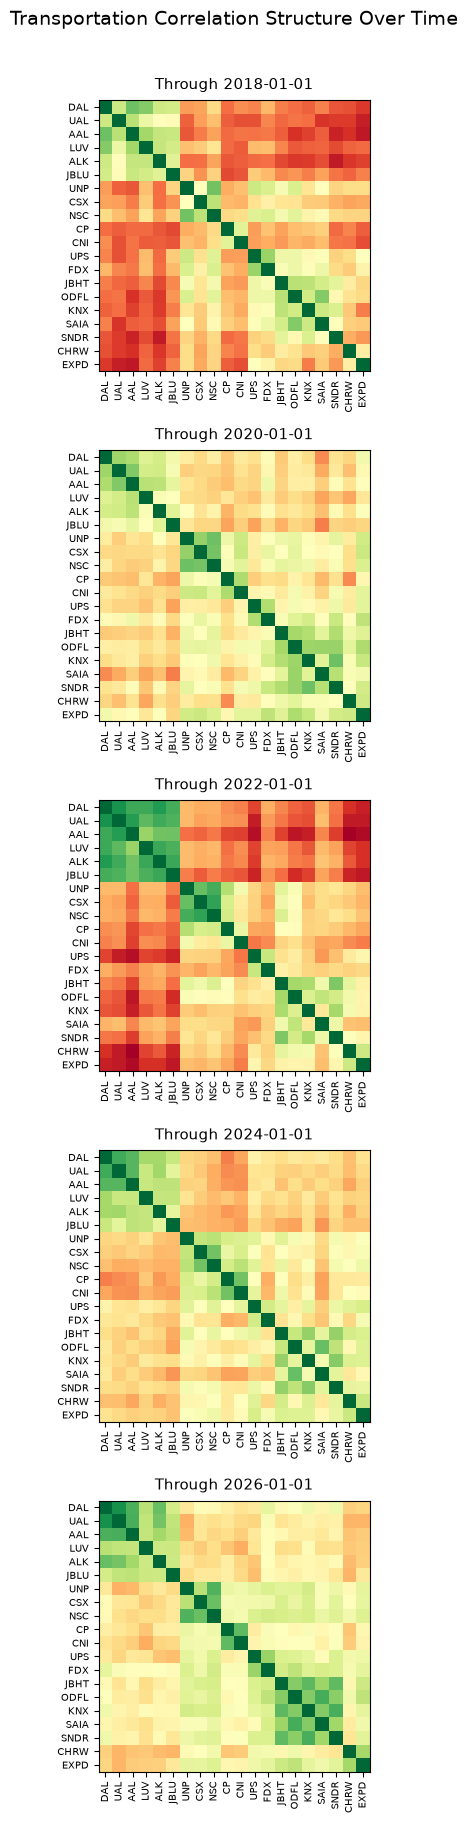

In [6]:
# How correlations in the transports space evolve over time
fig, axes = plt.subplots(5, 1, figsize = (14, 18))
dates = ['2018-01-01', '2020-01-01', '2022-01-01', '2024-01-01', '2026-01-01']
for ax, d in zip(axes, dates):
    subset = stocks_returns.loc[stocks_returns.index <= d].tail(252)
    corr = subset.corr()
    im = ax.imshow(corr, cmap = 'RdYlGn', vmin = 0, vmax = 1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation = 90, fontsize = 7)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns, fontsize = 7)
    ax.set_title(f"Through {d}", fontsize = 11, pad = 8)
plt.suptitle("Transportation Correlation Structure Over Time", fontsize = 14, y = 1.01)
plt.tight_layout()
plt.show()

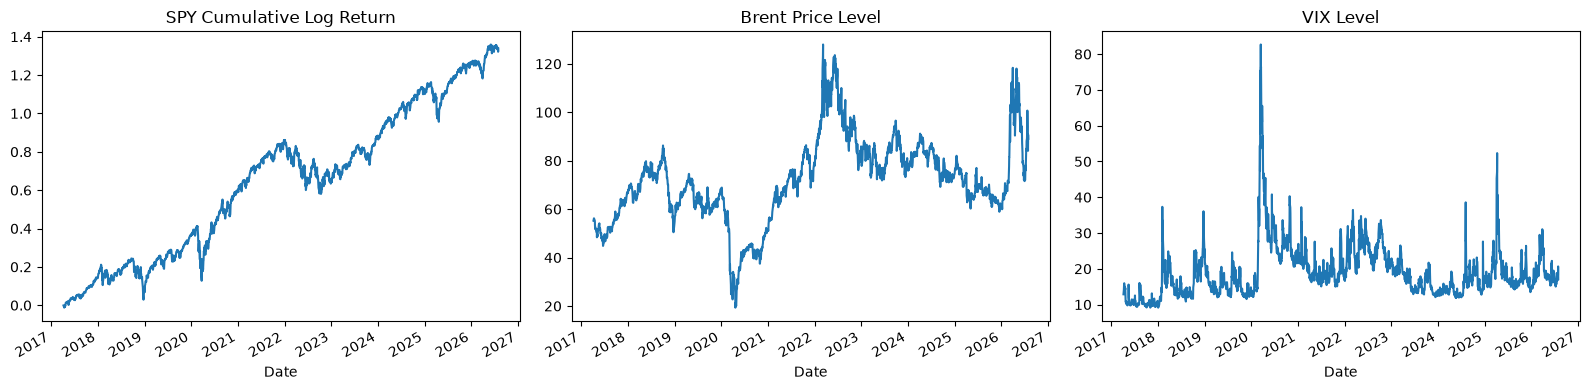

In [7]:
# Testing regime environments
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
macro_returns['SPY'].cumsum().plot(ax = axes[0], title = 'SPY Cumulative Log Return')
macro_returns['Brent'].plot(ax = axes[1], title = 'Brent Price Level')
macro_returns['VIX'].plot(ax = axes[2], title = 'VIX Level')

plt.tight_layout()
plt.show()

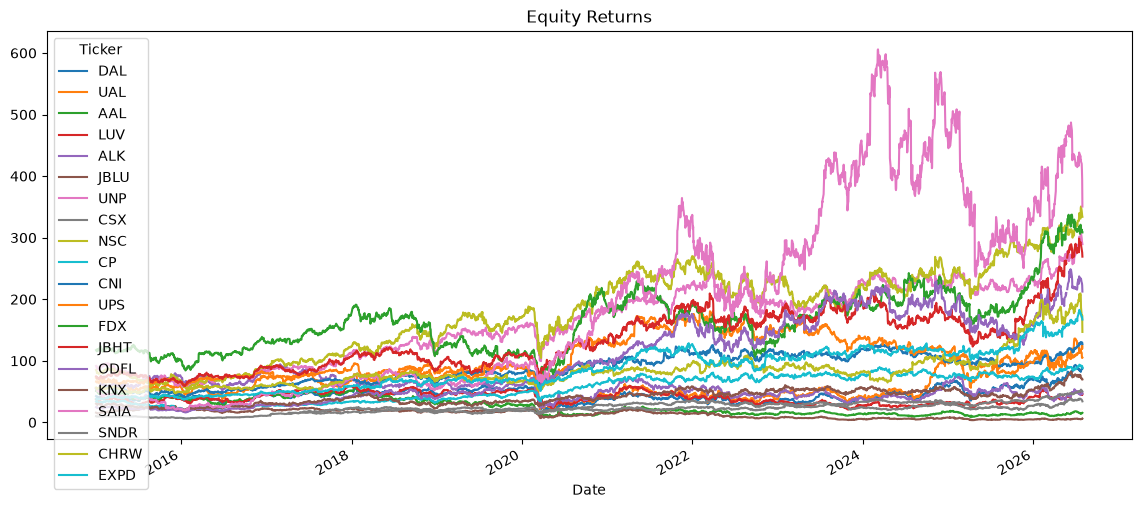

In [8]:
# Price Charts
prices[['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'UNP', 'CSX', 'NSC', 'CP', 'CNI', 'UPS', 'FDX', 'JBHT', 'ODFL', 'KNX', 'SAIA', 'SNDR', 'CHRW', 'EXPD']].plot(figsize = (14,6),title = "Equity Returns")
plt.show()

<Axes: title={'center': 'Rolling Volatility'}, xlabel='Date'>

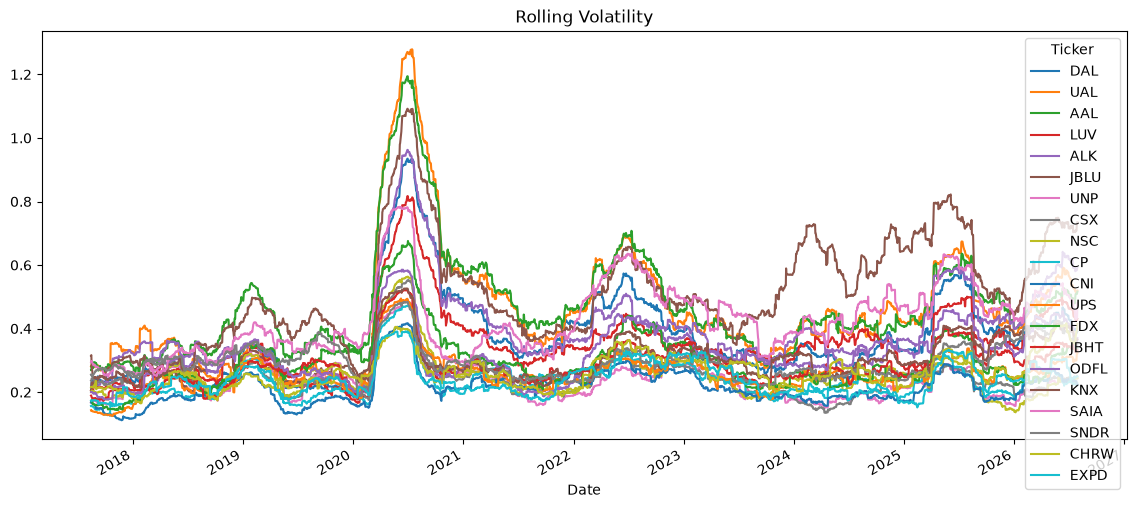

In [9]:
# Rolling Volatility
rolling_vol = stocks_returns.rolling(90).std() * np.sqrt(252)
rolling_vol.plot(figsize = (14,6), title = "Rolling Volatility")

In [10]:
# Thanks for your time, allow me to take you to the next Exhibit (02_Models.ipynb)!